<a href="https://colab.research.google.com/github/Gcarmnonapy7/FIAP-Aurora-Siger/blob/main/Aurora_siger.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Pipeline de Machine Learning

```
DATA LOADING & CLEANING → EDA → FEATURE ENGINEERING → DATA SPLITTING → TRAINING → VALIDATION ⇄ HYPERPARAMETER TUNING → SAVE ARTEFACT
```

> **Nota:** Validação e Hyperparameter Tuning formam um ciclo iterativo — ajusta-se, valida-se, repete-se até encontrar a melhor configuração.

| Etapa | O que faz |
|-------|-----------|
| **Data Loading & Cleaning** | Carregar os dados brutos e tratar valores ausentes, duplicados ou inconsistentes |
| **EDA** (Exploratory Data Analysis) | Visualizar distribuições, correlações e padrões para entender os dados antes de modelar |
| **Feature Engineering** | Criar, transformar ou selecionar variáveis que melhorem a capacidade preditiva do modelo |
| **Data Splitting** | Dividir em treino, validação e teste para avaliar o modelo em dados que ele nunca viu |
| **Training** | Ajustar os parâmetros do modelo aos dados de treino |
| **Validation** | Medir o desempenho em dados de validação para detectar overfitting ou underfitting |
| **Hyperparameter Tuning** | Otimizar configurações externas ao modelo (ex: número de árvores, kernel) que não são aprendidas no treino |
| **Save Artefact** | Serializar o modelo treinado (ex: `joblib`, `pickle`) para uso em produção |

In [29]:
# === import libraries ===

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

In [30]:
np.random.seed(42)
n_samples = 100_000
anomalies_ratio = 0.03
n_anomalies = int(n_samples * anomalies_ratio)

In [32]:
tank_pressure_data = np.random.normal(loc=305, scale=15, size=n_samples - n_anomalies)
failure_prob = 1 / (1 + np.exp(-(tank_pressure_data - 320) / 10)) # if too high change the number of the division
failure_prob = np.clip(failure_prob, 0, 1) # Ensure probabilities are between 0 and 1

df_non_anomaly = pd.DataFrame({
    'temperatura_interna': np.random.normal(loc=22, scale=1.5, size=n_samples - n_anomalies),       # ISS: 18–26°C, média 21–23°C
    'temperatura_externa': np.random.normal(loc=10, scale=8, size=n_samples - n_anomalies),         # LEO: -65°C a +125°C
    'integridade_estrutural': np.random.binomial(1, failure_prob),  # bernoulli distribution for when the pressure is to high (above 320)
    'energy': np.random.beta(8, 2, n_samples - n_anomalies) * 100,                      # carga da bateria (%)
    'vibration': np.random.normal(loc=0.3, scale=0.1, size=n_samples - n_anomalies),                 # pré-decolagem: ~0.1–0.5g
    'tank_pressure': tank_pressure_data,   # LOX/LH2 pump-fed (atm)
    'navegation' : np.random.binomial(1, 1 - failure_prob, size=n_samples - n_anomalies),
})

df_anomaly = pd.DataFrame({})

In [33]:
df.head()

,temperatura_interna,temperatura_externa,integridade_estrutural,energy,vibration,tank_pressure,navegation
0,22.795480,42.113008,0,73.114106,0.251835,325.174081,0
1,23.521472,9.231666,0,69.967352,0.317564,304.534454,1
2,23.129089,4.211693,1,91.241620,0.327137,311.019140,1
3,23.222178,2.759294,0,85.179708,0.288307,297.057506,1
4,21.657419,10.798639,0,92.131046,0.105596,296.120237,1


In [43]:
print(f'{df_non_anomaly.shape}')

(97000, 7)


In [35]:
df_non_anomaly.describe()

,temperatura_interna,temperatura_externa,integridade_estrutural,energy,vibration,tank_pressure,navegation
count,97000.000000,97000.000000,97000.000000,97000.000000,97000.000000,97000.000000,97000.000000
mean,22.001916,10.028548,0.253804,80.018714,0.300178,304.994967,0.745155
std,1.501812,8.004866,0.435189,12.048849,0.099988,14.967922,0.435777
min,15.380551,-26.388919,0.000000,13.143760,-0.146318,235.574152,0.000000
25%,20.990268,4.629692,0.000000,72.764074,0.232875,294.869585,0.000000
50%,22.003420,10.024031,0.000000,82.028682,0.300321,304.983879,1.000000
75%,23.011825,15.421437,1.000000,89.301287,0.367676,315.138149,1.000000
max,29.533069,45.198171,1.000000,99.957085,0.778888,373.355828,1.000000


## EDA (Exploratory data analysis)

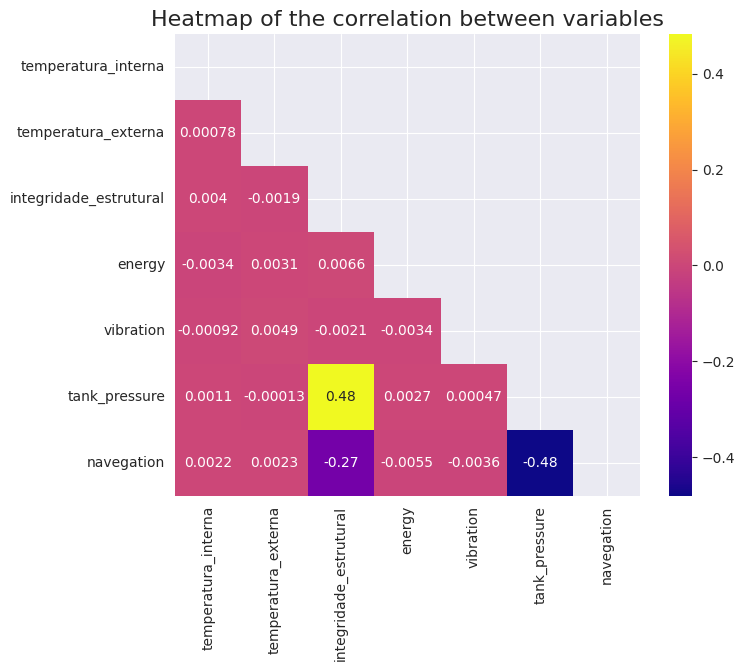

In [41]:
import seaborn
import matplotlib.pyplot as plt
sns.set_style('darkgrid')
TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 14

def heatmap_plot(data:pd.DataFrame):
    plt.figure(figsize=(7.5,6))
    plt.title('Heatmap of the correlation between variables', fontsize=TITLE_FONTSIZE)
    corr = data.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool)) # upper triangular for easier visualization
    sns.heatmap(corr,mask=mask,annot=True,fmt=".2g",cmap="plasma")
    plt.show()

def distribution_plot(data:pd.DataFrame):
    plt.figure(figsize=(7.5,6))
    plt.title('Distribution of the variables', fontsize=TITLE_FONTSIZE)
    for i, col in enumerate(data.columns):
        plt.subplot(nrows=, ncols=1,squeeze=True)

heatmap_plot(df_non_anomaly) # not so much correlated

##Creating the models from scratch

In [ ]:
# === Decision tree from scratch ===
class DecisionTree:
  def __init__(self):
    pass


In [ ]:
# Isolation tree from strach
class IsolationTree:
  def __init__(self):
    pass

---

# Entregáveis do Projeto Aurora SIGER

Roteiro de desenvolvimento do trabalho em grupo. Cada seção abaixo corresponde a um entregável da atividade.

## 1.1 Organização e descrição da telemetria

Interpretar dados referentes a:
- Temperatura interna e externa
- Integridade estrutural (0/1)
- Níveis de energia (%)
- Pressão dos tanques
- Status dos módulos críticos

## 1.2 Algoritmo de verificação

Construir um algoritmo (fluxograma/pseudocódigo) capaz de decidir:
- **"PRONTO PARA DECOLAR"** ou **"DECOLAGEM ABORTADA"**

Com base em faixas seguras predefinidas para cada variável de telemetria.

## 1.3 Script em Python

Implementar a lógica do algoritmo em Python, simulando:
- Leitura dos dados de telemetria
- Execução das verificações contra faixas seguras
- Resultado final impresso: **"PRONTO PARA DECOLAR"** ou **"DECOLAGEM ABORTADA"**

## 1.4 Análise energética

Calcular autonomia inicial considerando:
- Capacidade total (kWh)
- Carga atual (%)
- Consumo estimado na decolagem
- Perdas energéticas

## 1.5 Análise assistida por IA

Solicitar à IA:
- Classificação dos dados de telemetria
- Identificação de possíveis anomalias
- Sugestões de risco

## 1.6 Reflexão crítica

Texto sobre:
- Ética e responsabilidade no uso de IA e automação em sistemas críticos
- Impacto social da exploração espacial
- Sustentabilidade tecnológica